In [95]:
import numpy as np
import re
from tqdm import tqdm

import matplotlib.pyplot as plt
from PIL import Image
import os
import random

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Dropout, Concatenate,TextVectorization
from tensorflow.keras.models import Model

In [52]:
DATA_DIR = "/kaggle/input/notebooks/urmilvisariya/vqa-project-notebook-1/preprocessed"

train_data = np.load(DATA_DIR + "/train.npy", allow_pickle=True)
val_data   = np.load(DATA_DIR + "/val.npy", allow_pickle=True)

In [53]:
train_data

array([{'question': 'What is this photo taken looking through?', 'image_id': 458752, 'answer': 'net'},
       {'question': 'What position is this man playing?', 'image_id': 458752, 'answer': 'pitcher'},
       {'question': 'What color is the players shirt?', 'image_id': 458752, 'answer': 'orange'},
       ...,
       {'question': 'What color is the computer?', 'image_id': 524286, 'answer': 'black'},
       {'question': 'Why are there two keyboards?', 'image_id': 524286, 'answer': '<unk>'},
       {'question': 'Is that a laptop?', 'image_id': 524286, 'answer': 'yes'}],
      dtype=object)

In [54]:
FEATURE_DIR = "/kaggle/input/notebooks/urmilvisariya/vqa-project-notebook-2"

train_features = np.load(FEATURE_DIR + "/train_features.npy", allow_pickle=True).item()
val_features   = np.load(FEATURE_DIR + "/val_features.npy", allow_pickle=True).item()

In [55]:
# train_features

In [56]:
train_features[397205], len(train_features[397205])

(array([1.1468935 , 1.4587601 , 0.90247685, ..., 0.2934715 , 1.2740403 ,
        0.42609435], dtype=float32),
 2048)

In [57]:
available_ids = set(train_features.keys())

filtered_train_data = [
    item for item in train_data
    if item["image_id"] in available_ids
]

In [58]:
available_ids_val = set(val_features.keys())

filtered_val_data = [
    item for item in val_data
    if item["image_id"] in available_ids_val
]

### Prepare Questions

In [59]:
questions = [item["question"] for item in filtered_train_data]

### Finding optimal value of max_len and max_tokens

In [60]:
lengths = [len(q.split()) for q in questions]
print("Min:", np.min(lengths))
print("Max:", np.max(lengths))
print("Mean:", np.mean(lengths))
print("Median:", np.median(lengths))

for p in [50, 75, 90, 95, 99]:
    print(f"{p}th percentile:", np.percentile(lengths, p))

Min: 3
Max: 19
Mean: 6.24003984063745
Median: 6.0
50th percentile: 6.0
75th percentile: 7.0
90th percentile: 9.0
95th percentile: 10.0
99th percentile: 13.0


max_len = 12.0 will cover 99% of the question

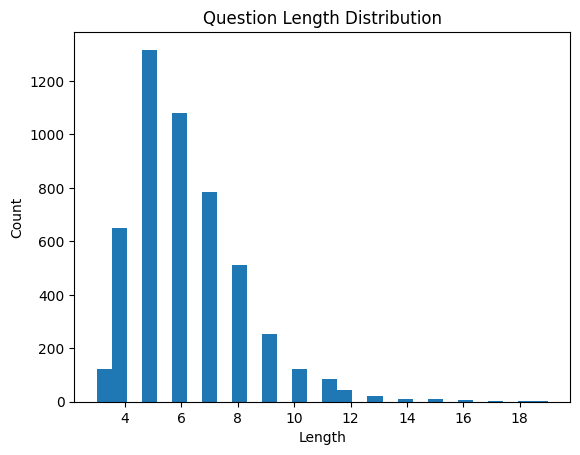

In [61]:
import matplotlib.pyplot as plt

plt.hist(lengths, bins=30)
plt.title("Question Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

In [62]:
vocab_path = DATA_DIR + "/Questions/question_vocab.txt"

word_freq = []

with open(vocab_path, 'r') as f:
    for line in f:
        word, count = line.rsplit(" ", 1)
        word_freq.append((word, int(count)))

In [63]:
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)

In [64]:
total_words = sum(count for _, count in word_freq)

Computer Coverage

In [65]:
coverage = []
cum_sum = 0

for i, (word, count) in enumerate(word_freq):
    cum_sum += count
    coverage.append((i+1, cum_sum / total_words))

In [66]:
for k in [1000, 2000, 3000,4000,5000,6000,7000,8000,9000, 10000]:
    cov = coverage[k-1][1]
    print(f"{k} words → {cov*100:.2f}% coverage")

1000 words → 93.63% coverage
2000 words → 96.92% coverage
3000 words → 98.14% coverage
4000 words → 98.76% coverage
5000 words → 99.12% coverage
6000 words → 99.36% coverage
7000 words → 99.52% coverage
8000 words → 99.64% coverage
9000 words → 99.73% coverage
10000 words → 99.79% coverage


max_tokens = 5000 words covers 99.12% of the words

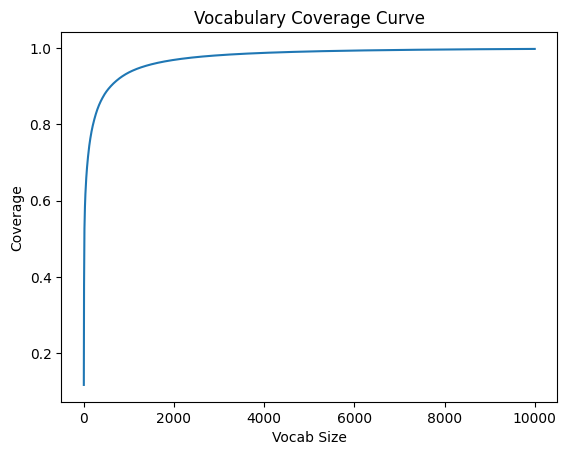

In [67]:
xs = [x[0] for x in coverage[:10000]]
ys = [x[1] for x in coverage[:10000]]

plt.plot(xs, ys)
plt.xlabel("Vocab Size")
plt.ylabel("Coverage")
plt.title("Vocabulary Coverage Curve")
plt.show()

In [68]:
max_len = 12
max_tokens = 3000

In [69]:
# custom_standarization to match preprocessing 
def custom_standardization(text):
    text = tf.strings.lower(text)
    text = tf.strings.regex_replace(text, r"[^\w\s]", "")
    return text

In [70]:
vectorizer = TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=max_len,
    standardize=custom_standardization
)

In [71]:
train_questions = [item["question"] for item in filtered_train_data]
val_questions   = [item["question"] for item in filtered_val_data]

vectorizer.adapt(train_questions)

Loading top-k answers to make them output of my mutli-class classification model

In [72]:
def load_answers(path):
    ans = []
    with open(path, 'r') as f:
        for line in f:
            a = line.rsplit(" ", 1)[0]
            ans.append(a)
    return ans

answer_vocab = load_answers(DATA_DIR + "/Annotations/answer_vocab.txt")

#### Remember: Almost 50% of the answers are yes/no so if getting bias result, add class weights later.

In [73]:
#Mapping answer to an index
ans_to_idx = {ans: i for i, ans in enumerate(answer_vocab)}
num_answers = len(answer_vocab)

In [74]:
num_answers

1000

In [75]:
#Converting answers to indexes
train_answers = [ans_to_idx.get(item["answer"], -1) for item in filtered_train_data]
val_answers   = [ans_to_idx.get(item["answer"], -1) for item in filtered_val_data]

In [76]:
#Filter questions whose answers is not in the top-k answers list
train_indices = [i for i, a in enumerate(train_answers) if a != -1]
val_indices   = [i for i, a in enumerate(val_answers) if a != -1]

train_answers = [train_answers[i] for i in train_indices]
val_answers   = [val_answers[i] for i in val_indices]

In [77]:
len(train_indices),len(val_indices)

(4387, 1779)

In [78]:
#One-hot encoding
train_y = to_categorical(train_answers, num_answers)
val_y   = to_categorical(val_answers, num_answers)

In [79]:
len(train_y),len(train_y[0]),len(val_y),len(val_y[0])

(4387, 1000, 1779, 1000)

In [80]:
train_img = np.array([
    train_features[item["image_id"]] for item in filtered_train_data
])[train_indices]

val_img = np.array([
    val_features[item["image_id"]] for item in filtered_val_data
])[val_indices]

In [81]:
len(train_img),len(val_img)

(4387, 1779)

In [82]:
train_questions = np.array(train_questions)[train_indices].reshape(-1, 1)
val_questions   = np.array(val_questions)[val_indices].reshape(-1, 1)

In [83]:
train_questions = tf.constant(train_questions)
val_questions   = tf.constant(val_questions)

In [84]:
len(train_questions),len(val_questions)

(4387, 1779)

In [85]:
train_questions[0]

<tf.Tensor: shape=(1,), dtype=string, numpy=array([b'What is this photo taken looking through?'], dtype=object)>

### Question encoder

In [86]:
# vectorizer.get_vocabulary()

In [87]:
vocab_size = len(vectorizer.get_vocabulary())
vocab_size

2490

In [88]:
q_encoder = tf.keras.Sequential([
    vectorizer,
    tf.keras.layers.Embedding(vocab_size, 256),   
    tf.keras.layers.LSTM(256),        # While training on full data set, hypertune no. of units here
    tf.keras.layers.Dropout(0.5)
])

### Image Encoder

In [89]:
img_encoder = tf.keras.Sequential([
    tf.keras.layers.Dense(512, activation='relu')
])

### Fusion Head

In [90]:
fusion_head = tf.keras.Sequential([
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_answers, activation='softmax')
])

In [91]:
q_input = tf.keras.Input(shape=(1,), dtype=tf.string)
img_input = tf.keras.Input(shape=(2048,))

q_feat = q_encoder(q_input)
img_feat = img_encoder(img_input)

combined = tf.keras.layers.Concatenate()([q_feat, img_feat])

output = fusion_head(combined)

model = tf.keras.Model(inputs=[q_input, img_input], outputs=output)

In [92]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [93]:
model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, 256)       │  1,162,752 │ input_layer_10[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_7        │ (None, 512)       │  1,049,088 │ input_layer_11[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 768)       │          0 │ sequential_6[0][… │
│ (Concatenate)       │                   │            │ sequential_7[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_8        │ (None, 1000)      │    906,728 │ concatenate_2[0]… │
│ (Sequential)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,118,568 (11.90 MB)

 Trainable params: 3,118,568 (11.90 MB)

 Non-trainable params: 0 (0.00 B)

In [94]:
model.fit(
    [train_questions, train_img],
    train_y,
    validation_data=(
        [val_questions, val_img],
        val_y
    ),
    epochs=15,
    batch_size=64
)

Epoch 1/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.1992 - loss: 4.7747 - val_accuracy: 0.2552 - val_loss: 3.5285
Epoch 2/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.2563 - loss: 3.3699 - val_accuracy: 0.2940 - val_loss: 3.2614
Epoch 3/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.3399 - loss: 2.9350 - val_accuracy: 0.2754 - val_loss: 3.1551
Epoch 4/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.3394 - loss: 2.7391 - val_accuracy: 0.2844 - val_loss: 3.1847
Epoch 5/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.3913 - loss: 2.3893 - val_accuracy: 0.2850 - val_loss: 3.0833
Epoch 6/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.4310 - loss: 2.1079 - val_accuracy: 0.2822 - val_loss: 3.0188
Epoch 7/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.4830 - loss: 1.8848 - val_accuracy: 0.2889 - val_loss: 3.0821
Epoch 8/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.5253 - loss: 1.6731 - val_accuracy: 0.2940 - v

### Prediction and visualization

In [109]:
test_data = np.load(DATA_DIR + "/test.npy", allow_pickle=True)
len(test_data)

447793

In [110]:
test_features = np.load(FEATURE_DIR + "/test_features.npy", allow_pickle=True).item()
len(test_features)

949

In [111]:
available_ids = set(test_features.keys())

print(len(available_ids))

filtered_test_data = [
    item for item in test_data
    if item["image_id"] in available_ids
]

print("Filtered test samples:", len(filtered_test_data))

949
Filtered test samples: 5007


In [99]:
test_questions = [item["question"] for item in filtered_test_data]
test_questions = np.array(test_questions).reshape(-1, 1)
test_questions = tf.constant(test_questions)

In [100]:
test_img = np.array([
    test_features[item["image_id"]]
    for item in filtered_test_data
])

In [101]:
preds = model.predict([test_questions, test_img])
pred_labels = np.argmax(preds, axis=1)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step


In [102]:
idx_to_ans = {i: ans for ans, i in ans_to_idx.items()}

pred_answers = [idx_to_ans[i] for i in pred_labels]

In [103]:
BASE = "/kaggle/input/datasets/mnhlfuch/vqa-v2/VQA v2/VQA v2"
TEST_IMG = BASE + "/Images/test2015"

def load_image_for_display(image_id):
    filename = f"COCO_test2015_{image_id:012d}.jpg"
    path = os.path.join(TEST_IMG, filename)
    
    image = Image.open(path).convert("RGB")
    return image

In [104]:
def show_prediction(idx):
    item = filtered_test_data[idx]
    
    image_id = item["image_id"]
    question = item["question"]
    prediction = pred_answers[idx]
    confidence = np.max(preds[idx])
    
    img = load_image_for_display(image_id)
    
    plt.imshow(img)
    plt.axis("off")
    
    plt.title(
        f"Q: {question}\nPred: {prediction} ({confidence:.2f})",
        fontsize=10
    )
    plt.show()

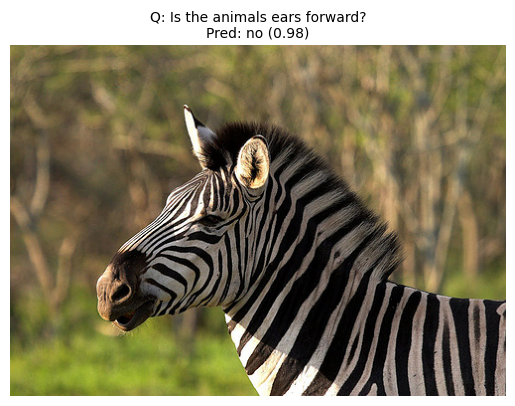

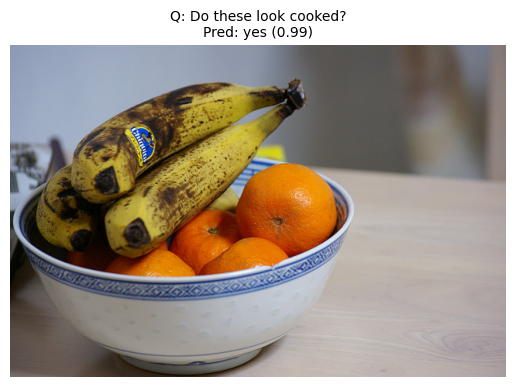

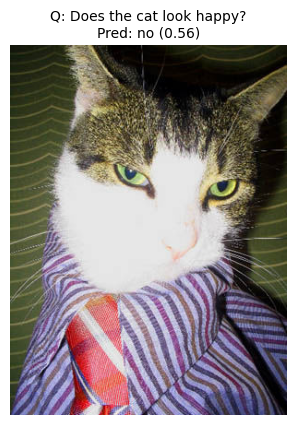

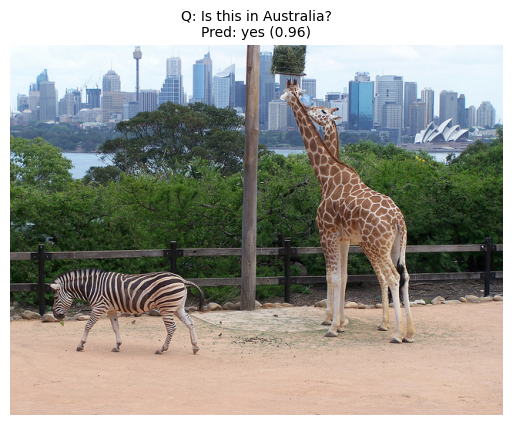

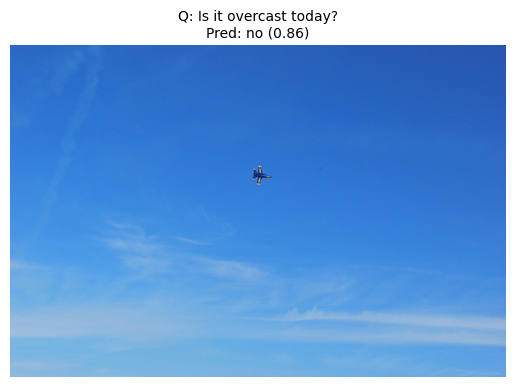

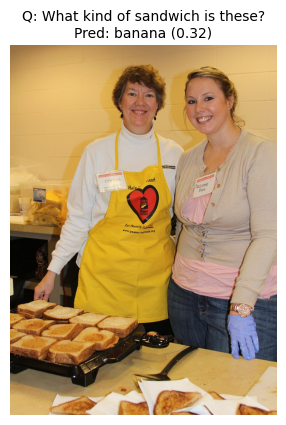

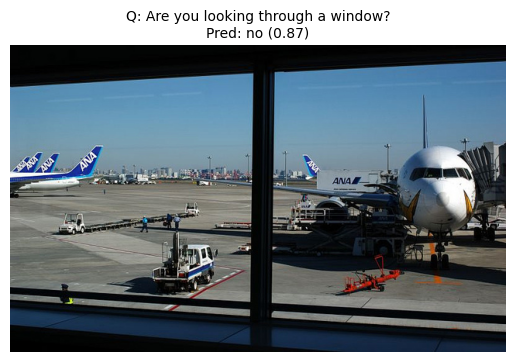

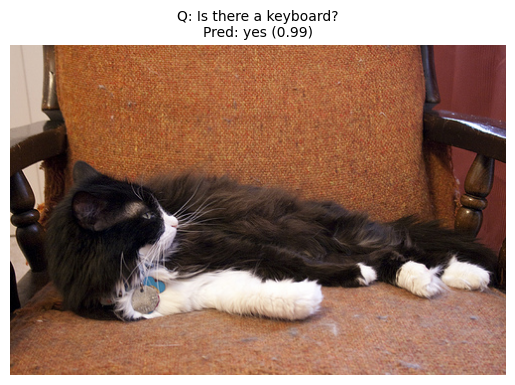

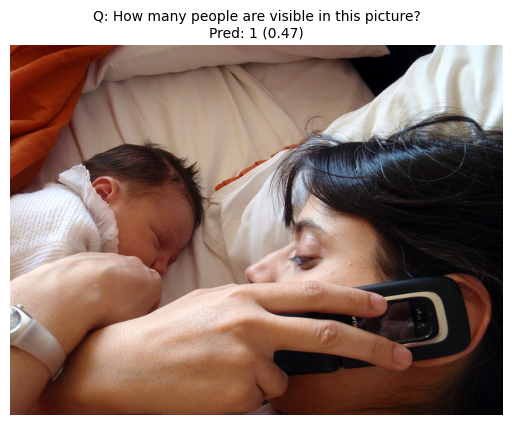

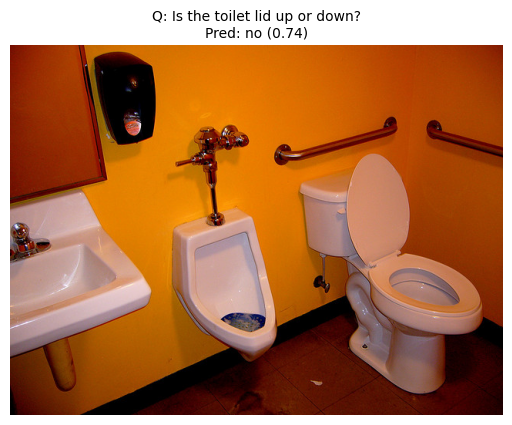

In [108]:
for _ in range(10):
    idx = random.randint(0, len(filtered_test_data) - 1)
    show_prediction(idx)

In [107]:
from collections import Counter
print(len(pred_answers))
print(Counter(pred_answers).most_common(10))

5007
[('yes', 1592), ('no', 702), ('1', 222), ('2', 165), ('none', 131), ('white', 118), ('blue', 95), ('3', 91), ('bathroom', 84), ('banana', 71)]
